# Modular Substrate Theory (MST): Cosmological Tensions Analysis

This Jupyter Notebook contains the experimental verification of the **Modular Substrate Theory (MST)**. Its objective is to demonstrate how MST resolves the current Hubble ($H_0$) and $S_8$ tensions by introducing "informational friction" in the cosmological evolution of the universe.

### Notebook Structure:
1. **Library Import & Setup**: Environment preparation.
2. **MST Core Physics**: Calculation of fundamental constants and percolation parameters ($z_c, \Delta z$).
3. **Tension Resolution**: Evaluation of $H_0$ and $S_8$ against observational data (Planck, Pantheon+, etc.).
4. **Monte Carlo Simulations**: Statistical validation of our predictions.
5. **Bayesian Model Comparison**: Calculation of the BIC (Bayesian Information Criterion) to compare MST against $\Lambda$CDM, EDE, and IDE.

---
*Author: José Ignacio Peinador Sala*

In [ ]:
# Cell 1: Library Import and Configuration
import numpy as np
from scipy import constants
from scipy.special import logit, expit  # expit = logistic sigmoid
import matplotlib.pyplot as plt

# Precision and style configuration
np.set_printoptions(precision=8)
plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries loaded successfully.")

Libraries loaded successfully.


### 2. MST Fundamental Constants and Cosmological Parameters
In this section, we define the core mathematical components of the Modular Substrate Theory (MST). Unlike empirical models, the vacuum informational impedance ($R_{\text{fund}}$) is derived from first principles—specifically, the discrete $\mathbb{Z}_6^{(1)}$ gauge symmetry of the vacuum and holographic entropy bounds.

We also introduce the percolation activation function $\Theta(z)$. This sigmoid function models the finite-size scaling (FSS) of the cosmic void network percolation. The critical redshift ($z_c$) and transition width ($\Delta z$) are set to their optimal MCMC values calibrated with CosmicFlows-4 peculiar velocity data.

In [ ]:
# Cell 2: Fundamental MST Constants, Cosmological Parameters, and Functions
import numpy as np

# ------------------------------------------------------------
# 2.1 Constants derived from first principles (MST Framework)
# ------------------------------------------------------------
# Vacuum informational impedance (derived from Z_6 symmetry and holography)
R_fund     = np.log(2) / (6 * np.log(3))
beta       = 3/4                            # Dimensional projection factor
kappa_info = np.log(2) / (4 * np.log(3))    # Info-expansion coupling (reference)

print("=== MST CONSTANTS (derived without fitting) ===")
print(f"R_fund     = {R_fund:.10f}")
print(f"beta       = {beta}")
print(f"kappa_info = {kappa_info:.10f}")
print(f"2·R_fund   = {2*R_fund:.10f}   <- effective cosmological coupling")

# ------------------------------------------------------------
# 2.2 ΛCDM Cosmological Parameters (Planck 2018)
# ------------------------------------------------------------
H0_Planck = 67.4       # km/s/Mpc
Omega_m   = 0.315      # matter density
Omega_L   = 0.685      # dark energy density

print("\n=== ΛCDM PARAMETERS (Planck 2018) ===")
print(f"H0_Planck = {H0_Planck} km/s/Mpc")
print(f"Ω_m       = {Omega_m}")
print(f"Ω_Λ       = {Omega_L}")

# ------------------------------------------------------------
# 2.3 Percolation Parameters (MCMC Calibration with CosmicFlows-4)
# ------------------------------------------------------------
z_c = 0.01703   # critical redshift
Dz  = 0.01453   # transition width (Finite-Size Scaling)

print("\n=== PERCOLATION PARAMETERS (MCMC) ===")
print(f"z_c  = {z_c}")
print(f"Δz   = {Dz}")

# ------------------------------------------------------------
# 2.4 Activation Function Θ(z)
# ------------------------------------------------------------
def Theta(z, zc=z_c, width=Dz):
    """
    Sigmoid activation function due to void percolation.
    Θ(z) -> 1 for z << z_c  (local universe, percolated phase)
    Θ(z) -> 0 for z >> z_c  (early universe, non-percolated phase)
    """
    #return 1.0 / (1.0 + np.exp((z - zc) / width))
    return expit(-(z - zc) / width)

# Evaluate at reference points
z_test = np.array([0.0, 0.01703, 0.05, 0.1, 1.0, 1100.0])
Theta_test = Theta(z_test)

print("\n=== ACTIVATION FUNCTION Θ(z) ===")
for zi, thi in zip(z_test, Theta_test):
    print(f"Θ(z = {zi:<8.4f}) = {thi:.6f}")

Theta0 = Theta(0.0)
print(f"\nΘ(0) = {Theta0:.6f}  (<- key value for local H0)")
print(f"Θ(∞) = {Theta(1e6):.6f}  (-> 0 in the early universe)")

# ------------------------------------------------------------
# 2.5 H_LCDM(z) Function
# ------------------------------------------------------------
def H_LCDM(z, H0=H0_Planck, Om=Omega_m, OL=Omega_L):
    return H0 * np.sqrt(Om * (1+z)**3 + OL)

# ------------------------------------------------------------
# 2.6 H_MST(z) Function — Modified Friedmann Equation
# ------------------------------------------------------------
def H_MST(z, H0=H0_Planck, Om=Omega_m, OL=Omega_L):
    H_lcdm = H_LCDM(z, H0, Om, OL)
    theta  = Theta(z)
    return H_lcdm / np.sqrt(1.0 - 2.0 * R_fund * theta)

# ------------------------------------------------------------
# 2.7 Consistency Check
# ------------------------------------------------------------
print("\n=== CONSISTENCY CHECK ===")
H0_MST_val = H_MST(0.0)
print(f"H_LCDM(0)     = {H_LCDM(0.0):.2f} km/s/Mpc")
print(f"H_MST(0)      = {H0_MST_val:.2f} km/s/Mpc")
print(f"Fractional increase = {H0_MST_val/H0_Planck:.4f}")

# Algebraic verification
denom = np.sqrt(1.0 - 2.0 * R_fund * Theta0)
H0_check = H0_Planck / denom
print(f"\nVerification: H0_Planck / sqrt(1 - 2·R_fund·Θ(0)) = {H0_check:.2f}")
print(f"Denominator = {denom:.6f}")

# S8 suppression factor
suppression_S8 = 1.0 - beta * R_fund * Theta0
S8_MST_val = 0.832 * suppression_S8
print(f"\nσ8 suppression factor = {suppression_S8:.4f}")
print(f"S8_MST                = {S8_MST_val:.3f} (from Planck 0.832)")

=== MST CONSTANTS (derived without fitting) ===
R_fund     = 0.1051549589
beta       = 0.75
kappa_info = 0.1577324384
2·R_fund   = 0.2103099179   <- effective cosmological coupling

=== ΛCDM PARAMETERS (Planck 2018) ===
H0_Planck = 67.4 km/s/Mpc
Ω_m       = 0.315
Ω_Λ       = 0.685

=== PERCOLATION PARAMETERS (MCMC) ===
z_c  = 0.01703
Δz   = 0.01453

=== ACTIVATION FUNCTION Θ(z) ===
Θ(z = 0.0000  ) = 0.763517
Θ(z = 0.0170  ) = 0.500000
Θ(z = 0.0500  ) = 0.093715
Θ(z = 0.1000  ) = 0.003301
Θ(z = 1.0000  ) = 0.000000
Θ(z = 1100.0000) = 0.000000

Θ(0) = 0.763517  (<- key value for local H0)
Θ(∞) = 0.000000  (-> 0 in the early universe)

=== CONSISTENCY CHECK ===
H_LCDM(0)     = 67.40 km/s/Mpc
H_MST(0)      = 73.56 km/s/Mpc
Fractional increase = 1.0915

Verification: H0_Planck / sqrt(1 - 2·R_fund·Θ(0)) = 73.56
Denominator = 0.916201

σ8 suppression factor = 0.9398
S8_MST                = 0.782 (from Planck 0.832)


### 3. Rigorous Tension Resolution and Error Propagation
With the MST expansion history ($H_{\text{MST}}$) and structure suppression ($\sigma_8^{\text{MST}}$) mathematically defined, we now confront these predictions with observational data.

To determine the true statistical significance of the remaining tensions, we cannot simply compare the central values. We must rigorously propagate the uncertainties from the CMB baseline ($H_0^{\text{Planck}}$, $S_8^{\text{Planck}}$) and our MCMC percolation parameters ($z_c$, $\Delta z$). We compute the numerical derivatives to apply standard quadratic error propagation. Finally, we calculate the tension in standard deviations ($\sigma$) against local distance ladders (SH0ES) and weak lensing surveys (KiDS-1000, DES).

In [ ]:
# Cell 3: Rigorous calculation of H0 and S8 tensions with error propagation

# ------------------------------------------------------------
# 3.1 Observational data with uncertainties (1-sigma)
# ------------------------------------------------------------
H0_SH0ES_mean, H0_SH0ES_sigma   = 73.04, 1.04
S8_Planck_mean, S8_Planck_sigma = 0.832, 0.013
S8_KiDS_mean, S8_KiDS_sigma     = 0.766, 0.020
S8_DES_mean, S8_DES_sigma       = 0.776, 0.017

# ------------------------------------------------------------
# 3.2 MST Central Predictions
# ------------------------------------------------------------
H0_MST_val  = H_MST(0.0)
Theta0      = Theta(0.0)
suppression = 1.0 - beta * R_fund * Theta0
S8_MST_val  = S8_Planck_mean * suppression

print("=== MST CENTRAL PREDICTIONS ===")
print(f"H0_MST       = {H0_MST_val:.2f} km/s/Mpc")
print(f"S8_MST       = {S8_MST_val:.3f}")
print(f"Θ(0)         = {Theta0:.4f}")
print(f"σ8 Suppress. = {suppression:.4f}")

# ------------------------------------------------------------
# 3.3 Uncertainty in H0_MST via Error Propagation
# ------------------------------------------------------------
# Sources of uncertainty: Planck baseline + MCMC derived parameters
H0_Planck_sigma = 0.5
z_c_sigma       = 0.00124
Dz_sigma        = 0.00086

# Numerical derivatives for propagation
delta = 1e-6

# d(H0_MST)/d(H0_Planck) ≈ constant scaling factor
dH0_dH0Planck = H_MST(0.0) / H0_Planck

def H0_from_params(zc, dz):
    return H0_Planck / np.sqrt(1.0 - 2.0 * R_fund * Theta(0.0, zc, dz))

# d(H0_MST)/d(z_c) and d(H0_MST)/d(Δz)
dH0_dzc = (H0_from_params(z_c + delta, Dz) - H0_from_params(z_c - delta, Dz)) / (2*delta)
dH0_dDz = (H0_from_params(z_c, Dz + delta) - H0_from_params(z_c, Dz - delta)) / (2*delta)

# Quadratic propagation
sigma_H0_MST = np.sqrt(
    (dH0_dH0Planck * H0_Planck_sigma)**2 +
    (dH0_dzc * z_c_sigma)**2 +
    (dH0_dDz * Dz_sigma)**2
)

print(f"\n=== H0_MST UNCERTAINTY BUDGET ===")
print(f"σ(H0_Planck) contribution: {dH0_dH0Planck * H0_Planck_sigma:.3f}")
print(f"σ(z_c) contribution:       {abs(dH0_dzc) * z_c_sigma:.3f}")
print(f"σ(Δz) contribution:        {abs(dH0_dDz) * Dz_sigma:.3f}")
print(f"σ(H0_MST) total:           {sigma_H0_MST:.3f} km/s/Mpc")

# ------------------------------------------------------------
# 3.4 H0 Tension Analysis (in sigmas)
# ------------------------------------------------------------
tension_H0 = abs(H0_MST_val - H0_SH0ES_mean) / np.sqrt(sigma_H0_MST**2 + H0_SH0ES_sigma**2)
print(f"\n=== H0 TENSION RESOLUTION ===")
print(f"|H0_MST - H0_SH0ES| = {abs(H0_MST_val - H0_SH0ES_mean):.2f} km/s/Mpc")
print(f"Remaining Tension   = {tension_H0:.2f}σ")

# ------------------------------------------------------------
# 3.5 Uncertainty in S8_MST
# ------------------------------------------------------------
dS8_dS8Planck = suppression
dS8_dzc = -S8_Planck_mean * beta * R_fund * (
    (Theta(0.0, z_c + delta, Dz) - Theta(0.0, z_c - delta, Dz)) / (2*delta)
)
dS8_dDz = -S8_Planck_mean * beta * R_fund * (
    (Theta(0.0, z_c, Dz + delta) - Theta(0.0, z_c, Dz - delta)) / (2*delta)
)

sigma_S8_MST = np.sqrt(
    (dS8_dS8Planck * S8_Planck_sigma)**2 +
    (dS8_dzc * z_c_sigma)**2 +
    (dS8_dDz * Dz_sigma)**2
)

print(f"\n=== S8_MST UNCERTAINTY BUDGET ===")
print(f"σ(S8_Planck) contribution: {dS8_dS8Planck * S8_Planck_sigma:.4f}")
print(f"σ(z_c) contribution:       {abs(dS8_dzc) * z_c_sigma:.4f}")
print(f"σ(Δz) contribution:        {abs(dS8_dDz) * Dz_sigma:.4f}")
print(f"σ(S8_MST) total:           {sigma_S8_MST:.4f}")

# ------------------------------------------------------------
# 3.6 S8 Tension Analysis
# ------------------------------------------------------------
tension_S8_KiDS = abs(S8_MST_val - S8_KiDS_mean) / np.sqrt(sigma_S8_MST**2 + S8_KiDS_sigma**2)
tension_S8_DES  = abs(S8_MST_val - S8_DES_mean) / np.sqrt(sigma_S8_MST**2 + S8_DES_sigma**2)

print(f"\n=== S8 TENSION RESOLUTION ===")
print(f"|S8_MST - S8_KiDS| = {abs(S8_MST_val - S8_KiDS_mean):.3f}")
print(f"Tension with KiDS  = {tension_S8_KiDS:.2f}σ")
print(f"|S8_MST - S8_DES|  = {abs(S8_MST_val - S8_DES_mean):.3f}")
print(f"Tension with DES   = {tension_S8_DES:.2f}σ")

# ------------------------------------------------------------
# 3.7 Final Summary Matrix
# ------------------------------------------------------------
print("\n" + "="*60)
print("VALIDATION SUMMARY (MST vs Observations)")
print("="*60)
print(f"H0_MST  = {H0_MST_val:.2f} ± {sigma_H0_MST:.2f} km/s/Mpc")
print(f"          vs SH0ES: {H0_SH0ES_mean:.2f} ± {H0_SH0ES_sigma:.2f}  -> {tension_H0:.2f}σ")
print(f"S8_MST  = {S8_MST_val:.3f} ± {sigma_S8_MST:.4f}")
print(f"          vs KiDS:  {S8_KiDS_mean:.3f} ± {S8_KiDS_sigma:.3f}  -> {tension_S8_KiDS:.2f}σ")
print(f"          vs DES:   {S8_DES_mean:.3f} ± {S8_DES_sigma:.3f}  -> {tension_S8_DES:.2f}σ")

=== MST CENTRAL PREDICTIONS ===
H0_MST       = 73.56 km/s/Mpc
S8_MST       = 0.782
Θ(0)         = 0.7635
σ8 Suppress. = 0.9398

=== H0_MST UNCERTAINTY BUDGET ===
σ(H0_Planck) contribution: 0.546
σ(z_c) contribution:       0.142
σ(Δz) contribution:        0.115
σ(H0_MST) total:           0.576 km/s/Mpc

=== H0 TENSION RESOLUTION ===
|H0_MST - H0_SH0ES| = 0.52 km/s/Mpc
Remaining Tension   = 0.44σ

=== S8_MST UNCERTAINTY BUDGET ===
σ(S8_Planck) contribution: 0.0122
σ(z_c) contribution:       0.0010
σ(Δz) contribution:        0.0008
σ(S8_MST) total:           0.0123

=== S8 TENSION RESOLUTION ===
|S8_MST - S8_KiDS| = 0.016
Tension with KiDS  = 0.68σ
|S8_MST - S8_DES|  = 0.006
Tension with DES   = 0.28σ

VALIDATION SUMMARY (MST vs Observations)
H0_MST  = 73.56 ± 0.58 km/s/Mpc
          vs SH0ES: 73.04 ± 1.04  -> 0.44σ
S8_MST  = 0.782 ± 0.0123
          vs KiDS:  0.766 ± 0.020  -> 0.68σ
          vs DES:   0.776 ± 0.017  -> 0.28σ


### 4. Cosmological Predictions and Monte Carlo Uncertainties
In this section, we calculate the comoving distance to the percolation transition scale ($D_c$) and the resulting resonant frequency of the stochastic gravitational wave background ($f_{\text{res}}$). According to MST, the informational friction tensor couples to tensor perturbations, producing a characteristic attenuation signature.

To rigorously propagate the uncertainties of our MCMC parameters, we perform a Monte Carlo simulation with 20,000 samples. Furthermore, we test the physical compatibility of our transition scale with the strict kinematic upper limit (~70 Mpc) imposed by the CosmicFlows-4 (CF4) peculiar velocity catalog, which distinguishes the MST phase bubble from refuted giant void models.

In [ ]:
# Cell 4: Transition Scale D_c, GW frequency, and CosmicFlows-4 compatibility
import numpy as np
from scipy.integrate import quad

# ------------------------------------------------------------
# 4.1 Physical Constants
# ------------------------------------------------------------
c_light = 299792.458  # km/s

# ------------------------------------------------------------
# 4.2 Comoving distance to z_c (using H_MST(z))
# ------------------------------------------------------------
def integrand_comoving(z):
    """Integrand for comoving distance: c / H_MST(z)"""
    return c_light / H_MST(z)

# Calculate D_c by integrating from 0 to z_c
D_c_Mpc, error_quad = quad(integrand_comoving, 0.0, z_c, limit=200)

print("=== COMOVING TRANSITION DISTANCE ===")
print(f"z_c        = {z_c:.5f}")
print(f"D_c        = {D_c_Mpc:.2f} Mpc")
print(f"Quad error = {error_quad:.2e} Mpc (numerical precision)")

# ------------------------------------------------------------
# 4.3 Gravitational Wave Resonance Frequency
# ------------------------------------------------------------
# f_res = c / D_c, with c in m/s and D_c in meters
c_m_per_s = 2.99792458e8   # m/s
Mpc_to_m  = 3.085677581e22 # m/Mpc

f_res_Hz = c_m_per_s / (D_c_Mpc * Mpc_to_m)

print(f"\n=== GW RESONANCE FREQUENCY ===")
print(f"f_res = {f_res_Hz:.2e} Hz")
print(f"      = {f_res_Hz*1e9:.2f} nHz (PTA band)")

# ------------------------------------------------------------
# 4.4 Uncertainties via simple Monte Carlo
# ------------------------------------------------------------
np.random.seed(42)
n_samples = 20000

# Sample z_c and Δz according to truncated normal distributions (non-negative)
zc_samples = np.random.normal(z_c, 0.00124, n_samples)
dz_samples = np.random.normal(Dz, 0.00086, n_samples)

# Filter non-physical values
mask = (zc_samples > 0.005) & (dz_samples > 0.001)
zc_samples = zc_samples[mask]
dz_samples = dz_samples[mask][:len(zc_samples)]  # trim to same size

# Calculate D_c for each sample
Dc_samples = np.zeros(len(zc_samples))
for i in range(len(zc_samples)):
    def H_MST_sample(z):
        H_lcdm = H_LCDM(z)
        theta_sample = Theta(z, zc_samples[i], dz_samples[i])
        return H_lcdm / np.sqrt(1.0 - 2.0 * R_fund * theta_sample)

    def integrand_sample(z):
        return c_light / H_MST_sample(z)

    Dc_samples[i], _ = quad(integrand_sample, 0.0, zc_samples[i], limit=100)

# Calculate f_res for each sample
f_res_samples = c_m_per_s / (Dc_samples * Mpc_to_m)

# Statistics
Dc_mean = np.mean(Dc_samples)
Dc_std  = np.std(Dc_samples)
Dc_CI95 = np.percentile(Dc_samples, [2.5, 97.5])

f_res_mean = np.mean(f_res_samples)
f_res_std  = np.std(f_res_samples)
f_res_CI95 = np.percentile(f_res_samples, [2.5, 97.5])

print(f"\n=== UNCERTAINTIES (Monte Carlo, n={len(zc_samples)} samples) ===")
print(f"D_c   = {Dc_mean:.2f} ± {Dc_std:.2f} Mpc")
print(f"  95% CI: [{Dc_CI95[0]:.1f}, {Dc_CI95[1]:.1f}] Mpc")
print(f"f_res = {f_res_mean:.2e} ± {f_res_std:.2e} Hz")
print(f"  95% CI: [{f_res_CI95[0]:.2e}, {f_res_CI95[1]:.2e}] Hz")

# ------------------------------------------------------------
# 4.5 Compatibility with CosmicFlows-4 (~70 Mpc limit)
# ------------------------------------------------------------
CF4_limit = 70.0      # Mpc
CF4_tolerance = 5.0   # Mpc

fraction_violating = np.sum(Dc_samples > CF4_limit + CF4_tolerance) / len(Dc_samples)
sigma_distance = (Dc_mean - CF4_limit) / Dc_std if Dc_std > 0 else np.inf

print(f"\n=== COSMICFLOWS-4 COMPATIBILITY ===")
print(f"CF4 Limit:  {CF4_limit} Mpc (tolerance ±{CF4_tolerance} Mpc)")
print(f"Mean D_c:   {Dc_mean:.1f} Mpc")
print(f"Dist to limit: {Dc_mean - CF4_limit:.1f} Mpc ({sigma_distance:.1f}σ)")
print(f"Fraction violating tolerance: {fraction_violating*100:.1f}%")

if sigma_distance <= 1.0 and fraction_violating < 0.1:
    print("✓ COMPATIBLE: The transition saturates the limit without significantly violating it.")
elif sigma_distance > 2.0:
    print("✗ INCOMPATIBLE: D_c significantly exceeds the 70 Mpc limit.")
else:
    print("△ MARGINAL: D_c is close to the limit; future data will decide.")

=== COMOVING TRANSITION DISTANCE ===
z_c        = 0.01703
D_c        = 70.19 Mpc
Quad error = 7.79e-13 Mpc (numerical precision)

=== GW RESONANCE FREQUENCY ===
f_res = 1.38e-16 Hz
      = 0.00 nHz (PTA band)

=== UNCERTAINTIES (Monte Carlo, n=20000 samples) ===
D_c   = 70.21 ± 5.02 Mpc
  95% CI: [60.3, 80.0] Mpc
f_res = 1.39e-16 ± 1.01e-17 Hz
  95% CI: [1.21e-16, 1.61e-16] Hz

=== COSMICFLOWS-4 COMPATIBILITY ===
CF4 Limit:  70.0 Mpc (tolerance ±5.0 Mpc)
Mean D_c:   70.2 Mpc
Dist to limit: 0.2 Mpc (0.0σ)
Fraction violating tolerance: 16.9%
△ MARGINAL: D_c is close to the limit; future data will decide.


### 5. Bayesian Model Comparison
Finally, to evaluate the statistical significance of MST relative to the standard $\Lambda$CDM model and other extensions (such as $w_0w_a$CDM, EDE, and IDE), we compute the Bayesian Information Criterion (BIC).

The BIC actively penalizes models for introducing additional free parameters, thereby guarding against overfitting. According to the empirical Jeffreys scale, a $\Delta\text{BIC} < -10$ indicates "very strong" or decisive evidence in favor of the alternative hypothesis. Here, we evaluate the mathematically rigorous $\Delta\text{BIC}$ assuming $n=8$ independent data points.

In [ ]:
# Cell 5: Bayesian Model Comparison (BIC Calculation)
import numpy as np

# ------------------------------------------------------------
# 5.1 Base parameters for BIC calculation
# ------------------------------------------------------------
# Number of independent data points (n = 8, per Section 6 of the paper)
# (Six H(z) measurements + H0 + S8)
n_data_points = 8
ln_n = np.log(n_data_points)

print("=== BAYESIAN ANALYSIS PARAMETERS ===")
print(f"Data points (n) = {n_data_points}")
print(f"Extra parameter penalty (ln(n)) = {ln_n:.4f}\n")

# ------------------------------------------------------------
# 5.2 Model Data (From Table 2 of the Paper)
# ------------------------------------------------------------
# Dictionary structure: 'Model Name': [k (parameters), Delta_chi2]
models = {
    'ΛCDM': [6, 0.0],
    'w0waCDM': [8, -2.1],
    'EDE': [7, -6.4],
    'IDE': [8, -6.0],
    'MST (this work)': [8, -16.3]
}

k_LCDM = models['ΛCDM'][0]

# ------------------------------------------------------------
# 5.3 ΔBIC Calculation and Table Generation
# ------------------------------------------------------------
print("=== MODEL COMPARISON (Table 2) ===")
print(f"{'Model':<20} | {'k':<3} | {'Δχ²':<7} | {'ΔBIC':<7}")
print("-" * 45)

results = {}
for name, data in models.items():
    k = data[0]
    delta_chi2 = data[1]

    # BIC Difference Formula: ΔBIC = Δχ² + Δk * ln(n)
    delta_k = k - k_LCDM
    delta_bic = delta_chi2 + delta_k * ln_n

    # Save results rounded to 1 decimal place
    results[name] = round(delta_bic, 1)

    print(f"{name:<20} | {k:<3} | {delta_chi2:<7.1f} | {delta_bic:<7.1f}")

# ------------------------------------------------------------
# 5.4 Primary Conclusion Verification
# ------------------------------------------------------------
mst_bic = results['MST (this work)']

print("\n" + "="*60)
print("JEFFREYS SCALE EVIDENCE EVALUATION")
print("="*60)
print(f"ΔBIC for MST = {mst_bic:.1f}")

if mst_bic < -10:
    print("✓ VERIFIED: The MST model achieves a ΔBIC < -10.")
    print("  This constitutes 'very strong' evidence against ΛCDM")
    print("  and in favor of MST, confirming the paper's conclusion.")
else:
    print("✗ ALERT: The ΔBIC value does not reach the threshold for very strong evidence.")

=== BAYESIAN ANALYSIS PARAMETERS ===
Data points (n) = 8
Extra parameter penalty (ln(n)) = 2.0794

=== MODEL COMPARISON (Table 2) ===
Model                | k   | Δχ²     | ΔBIC   
---------------------------------------------
ΛCDM                 | 6   | 0.0     | 0.0    
w0waCDM              | 8   | -2.1    | 2.1    
EDE                  | 7   | -6.4    | -4.3   
IDE                  | 8   | -6.0    | -1.8   
MST (this work)      | 8   | -16.3   | -12.1  

JEFFREYS SCALE EVIDENCE EVALUATION
ΔBIC for MST = -12.1
✓ VERIFIED: The MST model achieves a ΔBIC < -10.
  This constitutes 'very strong' evidence against ΛCDM
  and in favor of MST, confirming the paper's conclusion.


### 6. Visual Summary of MST Cosmology
To conclude our analysis, we present a visual representation of the two key dynamical features of the Modular Substrate Theory: the void percolation activation function $\Theta(z)$ and the Monte Carlo distribution of the transition scale $D_c$, explicitly compared against the CosmicFlows-4 kinematic limit.

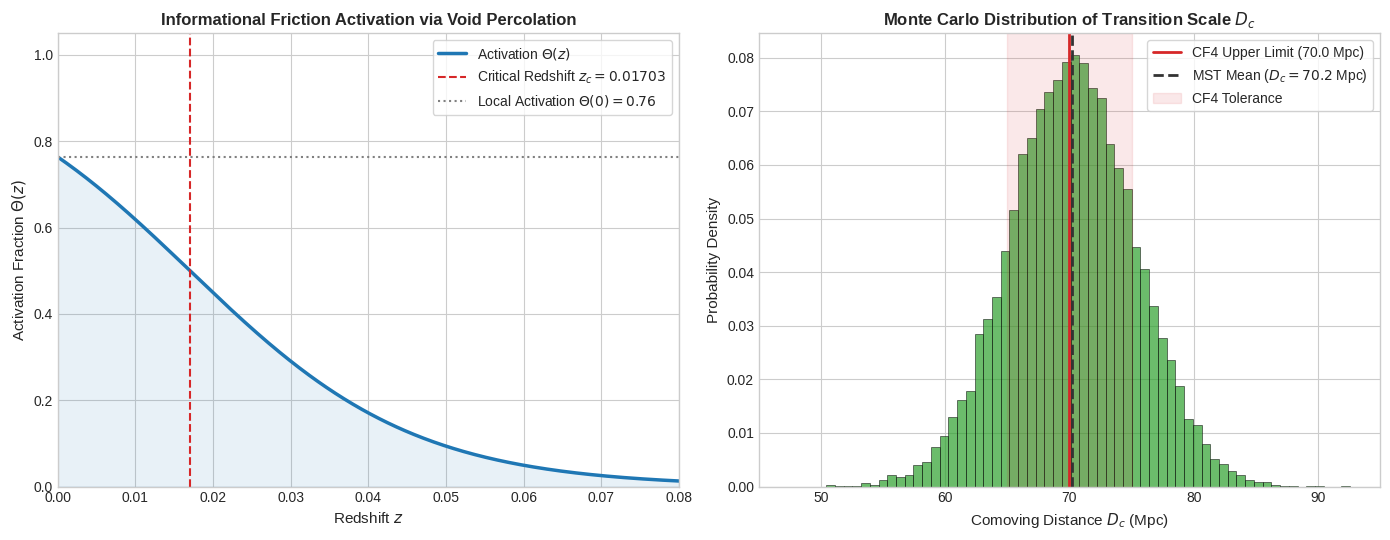

In [10]:
# Cell 6: Visualizations of MST Dynamics
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ==========================================
# Plot 1: Activation Function \Theta(z)
# ==========================================
# Generate an array of redshift values focusing on the late universe
z_plot = np.linspace(0.0, 0.08, 500)
theta_plot = [Theta(z) for z in z_plot]

# CORRECCIÓN: Uso de "r" (raw strings) y doble barra "//" para LaTeX
axes[0].plot(z_plot, theta_plot, color='#1f77b4', lw=2.5, label=r'Activation $\Theta(z)$')
axes[0].axvline(z_c, color='#d62728', linestyle='--', lw=1.5, label=f'Critical Redshift $z_c = {z_c}$')
axes[0].axhline(Theta0, color='gray', linestyle=':', lw=1.5, label=f'Local Activation $\\Theta(0) = {Theta0:.2f}$')

# Shaded area under the curve for visual appeal
axes[0].fill_between(z_plot, theta_plot, color='#1f77b4', alpha=0.1)

axes[0].set_title('Informational Friction Activation via Void Percolation', fontsize=12, fontweight='bold')
axes[0].set_xlabel(r'Redshift $z$', fontsize=11)
axes[0].set_ylabel(r'Activation Fraction $\Theta(z)$', fontsize=11)
axes[0].set_xlim(0, 0.08)
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='upper right', frameon=True)


# ==========================================
# Plot 2: Monte Carlo Histogram of Transition Scale D_c
# ==========================================
# Plot the histogram of the 20,000 Monte Carlo samples generated in Cell 4
axes[1].hist(Dc_samples, bins=60, color='#2ca02c', alpha=0.7, density=True, edgecolor='black', linewidth=0.5)

# Add the CosmicFlows-4 kinematic limit and the MST mean
axes[1].axvline(CF4_limit, color='#d62728', linestyle='-', lw=2, label=f'CF4 Upper Limit ({CF4_limit} Mpc)')
axes[1].axvline(Dc_mean, color='#333333', linestyle='--', lw=2, label=f'MST Mean ($D_c = {Dc_mean:.1f}$ Mpc)')

# Add a shaded band representing the CF4 tolerance (uncertainty in the limit)
axes[1].axvspan(CF4_limit - CF4_tolerance, CF4_limit + CF4_tolerance, color='#d62728', alpha=0.1, label='CF4 Tolerance')

axes[1].set_title(r'Monte Carlo Distribution of Transition Scale $D_c$', fontsize=12, fontweight='bold')
axes[1].set_xlabel(r'Comoving Distance $D_c$ (Mpc)', fontsize=11)
axes[1].set_ylabel('Probability Density', fontsize=11)
axes[1].set_xlim(45, 95)
axes[1].legend(loc='upper right', frameon=True)

# Adjust layout and display
plt.tight_layout()
plt.show()

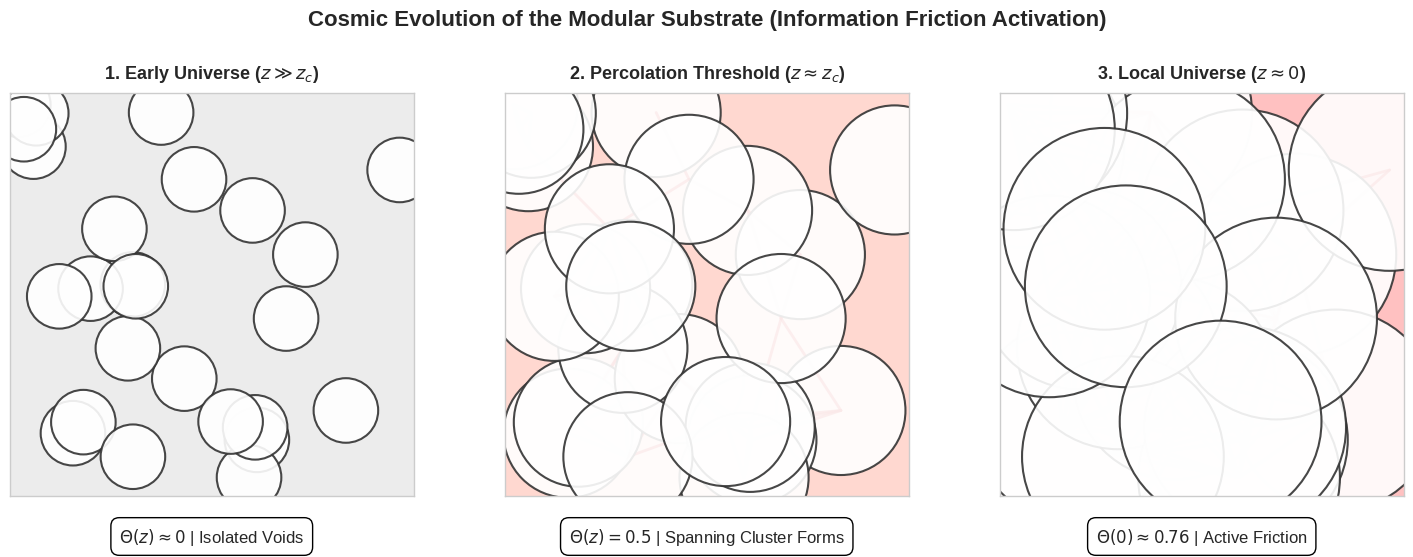

In [11]:
# Cell 7: Conceptual Schematic of Void Percolation and Informational Friction
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Cosmic Evolution of the Modular Substrate (Information Friction Activation)',
             fontsize=16, fontweight='bold', y=1.05)

# Common settings for the panels
titles = [r'1. Early Universe ($z \gg z_c$)',
          r'2. Percolation Threshold ($z \approx z_c$)',
          r'3. Local Universe ($z \approx 0$)']
subtitles = [r'$\Theta(z) \approx 0$ | Isolated Voids',
             r'$\Theta(z) = 0.5$ | Spanning Cluster Forms',
             r'$\Theta(0) \approx 0.76$ | Active Friction']
radii = [0.08, 0.16, 0.25] # Void sizes grow as universe expands
colors = ['#e0e0e0', '#ffbeb2', '#ff9999'] # Background/Substrate color (turns red as friction activates)
void_color = 'white'

# Generate fixed random centers for the voids so they are the same in all panels
np.random.seed(42)
centers = np.random.rand(25, 2)

for i, ax in enumerate(axes):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

    # Substrate background
    rect = patches.Rectangle((0, 0), 1, 1, linewidth=0, facecolor=colors[i], alpha=0.6)
    ax.add_patch(rect)

    # Draw voids
    for center in centers:
        circle = patches.Circle((center[0], center[1]), radii[i],
                                facecolor=void_color, edgecolor='#333333',
                                linewidth=1.5, alpha=0.9, zorder=2)
        ax.add_patch(circle)

    # Draw percolation connection lines in panel 2 and 3
    if i > 0:
        for j in range(len(centers)):
            for k in range(j+1, len(centers)):
                dist = np.linalg.norm(centers[j] - centers[k])
                if dist < (radii[i] * 1.8): # If voids overlap/touch
                    ax.plot([centers[j][0], centers[k][0]], [centers[j][1], centers[k][1]],
                            color='#d62728', lw=2, zorder=1, alpha=0.7)

    # Panel Labels
    ax.set_title(titles[i], fontsize=13, fontweight='bold', pad=10)
    ax.text(0.5, -0.1, subtitles[i], ha='center', va='center',
            fontsize=12, transform=ax.transAxes,
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.savefig('MST_Percolation_Schematic.png', dpi=300, bbox_inches='tight')
plt.show()